# Simulasi Quick Count Pemilu - Kota Semarang 2024
Notebook ini mengimplementasikan simulasi Quick Count pemilihan umum di Kota Semarang menggunakan pendekatan survei sampling (Cochran, 1977; Kish, 1965).
Analisis mencakup evaluasi populasi TPS, parameter proporsi riil, implementasi 5 metode sampling, komparasi error analitis, simulasi Monte Carlo berulang, kurva sensitivitas ukuran sampel, distribusi sampling, dan rekomendasi metode berbasis data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.axisbelow'] = True

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

FILE_PATH = 'quickcount_tps_kota_semarang_2024.xlsx'
df_raw = pd.read_excel(FILE_PATH)

print(f"Dataset dimuat: {len(df_raw):,} TPS, {df_raw.shape[1]} kolom.")
df_raw.head()

Dataset dimuat: 4,856 TPS, 11 kolom.


,id_tps,kabupaten_kota,kecamatan,kelurahan,nomor_tps,dpt,total_suara_sah,suara_paslon_01,suara_paslon_02,suara_paslon_03,proporsi_paslon_02
0,TPS-0001,KOTA SEMARANG,Banyumanik,Banyumanik Kel-1,TPS 001,300,239,25,117,97,0.4895
1,TPS-0002,KOTA SEMARANG,Banyumanik,Banyumanik Kel-1,TPS 002,259,202,16,92,94,0.4554
2,TPS-0003,KOTA SEMARANG,Banyumanik,Banyumanik Kel-1,TPS 003,293,236,33,119,84,0.5042
3,TPS-0004,KOTA SEMARANG,Banyumanik,Banyumanik Kel-1,TPS 004,250,213,59,85,69,0.3991
4,TPS-0005,KOTA SEMARANG,Banyumanik,Banyumanik Kel-1,TPS 005,292,253,47,107,99,0.4229


## 1. Pemilihan Wilayah dan Informasi Populasi TPS
Konfigurasi filter wilayah dan ringkasan demografi TPS di Kota Semarang.

In [2]:
# Konfigurasi wilayah target: 'SEMUA' untuk seluruh Kota Semarang, atau masukkan nama kecamatan tertentu
# Contoh kecamatan: 'Banyumanik', 'Pedurungan', 'Tembalang', 'Semarang Barat', dll.
TARGET_WILAYAH = 'SEMUA'

def get_populasi_data(df, wilayah='SEMUA'):
    if wilayah.upper() != 'SEMUA':
        df_filtered = df[df['kecamatan'].str.upper() == wilayah.upper()].copy().reset_index(drop=True)
    else:
        df_filtered = df.copy().reset_index(drop=True)
    return df_filtered

df_pop = get_populasi_data(df_raw, TARGET_WILAYAH)

N_pop = len(df_pop)
total_dpt = df_pop['dpt'].sum()
total_sah = df_pop['total_suara_sah'].sum()
turnout_rate = (total_sah / total_dpt) * 100
n_kec = df_pop['kecamatan'].nunique()
n_kel = df_pop['kelurahan'].nunique()

pop_summary = pd.DataFrame({
    'Indikator Populasi': [
        'Wilayah Terpilih',
        'Jumlah TPS (N Populasi)',
        'Jumlah Kecamatan',
        'Jumlah Kelurahan',
        'Total DPT Terdaftar',
        'Total Suara Sah Terhitung',
        'Tingkat Partisipasi Pemilih (Turnout)',
        'Rata-rata Suara Sah per TPS',
        'Standar Deviasi Suara Sah per TPS'
    ],
    'Nilai': [
        TARGET_WILAYAH,
        f"{N_pop:,} TPS",
        f"{n_kec}",
        f"{n_kel}",
        f"{total_dpt:,} jiwa",
        f"{total_sah:,} suara",
        f"{turnout_rate:.2f}%",
        f"{df_pop['total_suara_sah'].mean():.2f}",
        f"{df_pop['total_suara_sah'].std():.2f}"
    ]
})

pop_summary

,Indikator Populasi,Nilai
0,Wilayah Terpilih,SEMUA
1,Jumlah TPS (N Populasi),"4,856 TPS"
2,Jumlah Kecamatan,16
3,Jumlah Kelurahan,177
4,Total DPT Terdaftar,"1,305,098 jiwa"
5,Total Suara Sah Terhitung,"1,079,567 suara"
6,Tingkat Partisipasi Pemilih (Turnout),82.72%
7,Rata-rata Suara Sah per TPS,222.32
8,Standar Deviasi Suara Sah per TPS,17.45


In [3]:
rekap_kec = df_pop.groupby('kecamatan').agg(
    jumlah_kelurahan=('kelurahan', 'nunique'),
    jumlah_tps=('id_tps', 'count'),
    total_dpt=('dpt', 'sum'),
    total_suara_sah=('total_suara_sah', 'sum')
).reset_index()

rekap_kec['persen_tps'] = (rekap_kec['jumlah_tps'] / N_pop) * 100
rekap_kec['turnout_pct'] = (rekap_kec['total_suara_sah'] / rekap_kec['total_dpt']) * 100
rekap_kec = rekap_kec.sort_values(by='jumlah_tps', ascending=False).reset_index(drop=True)

rekap_kec

,kecamatan,jumlah_kelurahan,jumlah_tps,total_dpt,total_suara_sah,persen_tps,turnout_pct
0,Pedurungan,12,532,143235,118581,10.9555,82.7877
1,Semarang Barat,16,480,129416,107076,9.8847,82.7378
2,Tembalang,12,450,121033,99970,9.2669,82.5973
3,Banyumanik,11,412,111129,91678,8.4843,82.4969
4,Ngaliyan,10,395,106479,88105,8.1343,82.7440
5,Semarang Utara,9,368,98751,81732,7.5783,82.7657
6,Genuk,13,345,92271,76294,7.1046,82.6847
7,Gunungpati,16,290,77980,64504,5.9720,82.7186
8,Candisari,7,235,62955,52015,4.8394,82.6225
9,Semarang Timur,10,222,59530,49228,4.5717,82.6944


## 2. Perhitungan Parameter Proporsi Populasi (Ground Truth)
Parameter proporsi dihitung menggunakan ratio estimator populasi terhadap seluruh suara sah:
$$P_k = \frac{\sum_{i=1}^N Y_{k, i}}{\sum_{i=1}^N M_i}$$

In [4]:
P_01 = df_pop['suara_paslon_01'].sum() / total_sah
P_02 = df_pop['suara_paslon_02'].sum() / total_sah
P_03 = df_pop['suara_paslon_03'].sum() / total_sah

ground_truth = pd.DataFrame({
    'Pasangan Calon': ['Paslon 01', 'Paslon 02', 'Paslon 03'],
    'Total Suara Riil': [
        df_pop['suara_paslon_01'].sum(),
        df_pop['suara_paslon_02'].sum(),
        df_pop['suara_paslon_03'].sum()
    ],
    'Proporsi Populasi (P)': [P_01, P_02, P_03],
    'Persentase Populasi (%)': [P_01 * 100, P_02 * 100, P_03 * 100],
    'Rata-rata Suara per TPS': [
        df_pop['suara_paslon_01'].mean(),
        df_pop['suara_paslon_02'].mean(),
        df_pop['suara_paslon_03'].mean()
    ],
    'Std Dev Suara per TPS': [
        df_pop['suara_paslon_01'].std(),
        df_pop['suara_paslon_02'].std(),
        df_pop['suara_paslon_03'].std()
    ]
})

ground_truth

,Pasangan Calon,Total Suara Riil,Proporsi Populasi (P),Persentase Populasi (%),Rata-rata Suara per TPS,Std Dev Suara per TPS
0,Paslon 01,161340,0.1494,14.9449,33.2249,16.1546
1,Paslon 02,518789,0.4806,48.0553,106.8346,15.7508
2,Paslon 03,399438,0.3700,36.9998,82.2566,14.4936


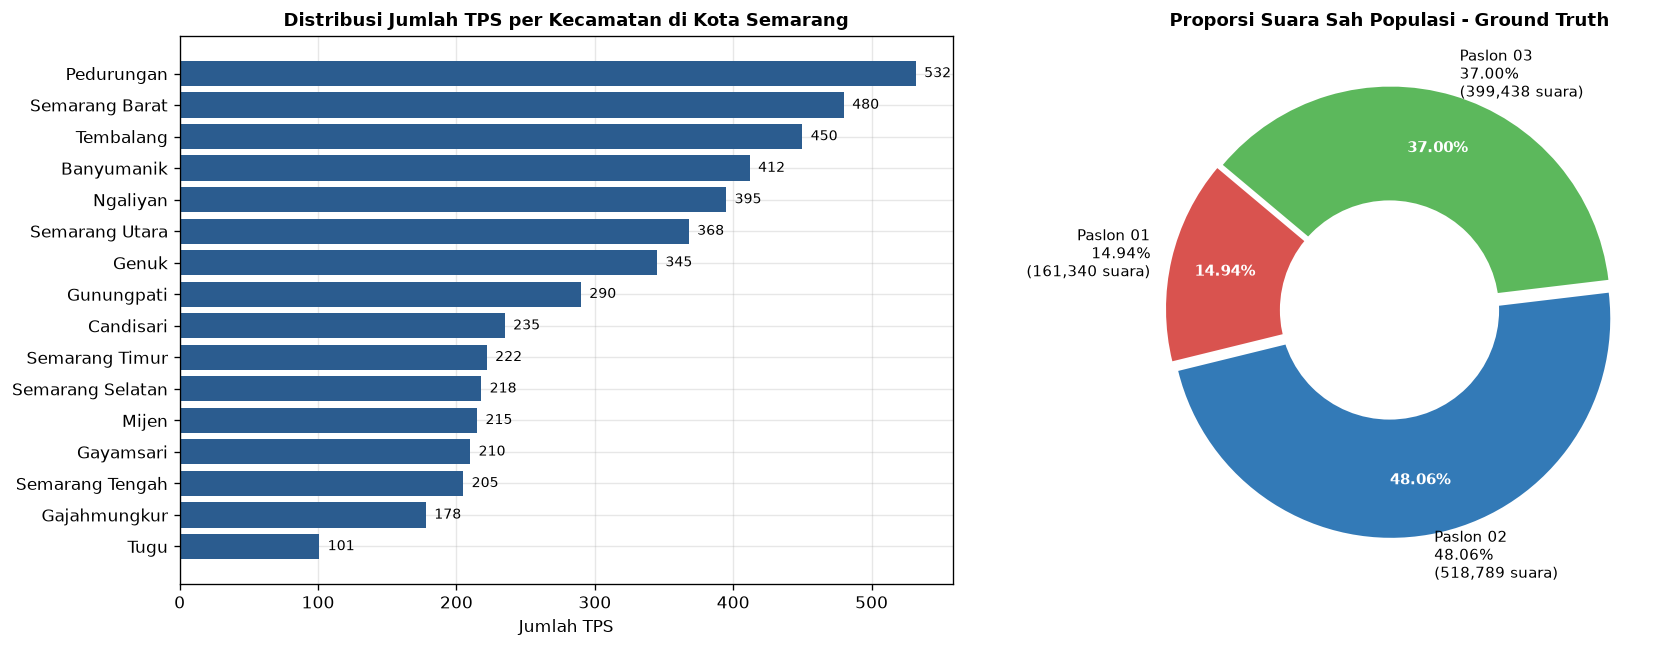

In [5]:
# Visualisasi Profil Populasi: Bar Chart TPS per Kecamatan & Pie Chart Proporsi Suara
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Subplot 1: Bar Chart Horizontal TPS per Kecamatan
rekap_sorted = df_pop.groupby('kecamatan')['id_tps'].count().sort_values(ascending=True)
bars = axes[0].barh(rekap_sorted.index, rekap_sorted.values, color='#2b5c8f', edgecolor='none')
axes[0].set_title('Distribusi Jumlah TPS per Kecamatan di Kota Semarang', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Jumlah TPS', fontsize=10)
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 6, bar.get_y() + bar.get_height()/2, f"{int(w)}", va='center', fontsize=8.5)

# Subplot 2: Pie / Donut Chart Perolehan Suara Paslon (Ground Truth)
colors_paslon = ['#d9534f', '#337ab7', '#5cb85c']
labels_paslon = [
    f"Paslon 01\n{P_01*100:.2f}%\n({df_pop['suara_paslon_01'].sum():,} suara)",
    f"Paslon 02\n{P_02*100:.2f}%\n({df_pop['suara_paslon_02'].sum():,} suara)",
    f"Paslon 03\n{P_03*100:.2f}%\n({df_pop['suara_paslon_03'].sum():,} suara)"
]
explode = (0.02, 0.04, 0.02)
wedges, texts, autotexts = axes[1].pie(
    [P_01, P_02, P_03], labels=labels_paslon, autopct='%1.2f%%', startangle=140,
    colors=colors_paslon, explode=explode, pctdistance=0.75,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_color('white')
    at.set_weight('bold')

# Membuat gaya donut chart
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Proporsi Suara Sah Populasi - Ground Truth', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Implementasi 5 Metode Sampling Survei
Metode sampling yang dianalisis:
1. SRS without replacement (SRSWOR)
2. SRS with replacement (SRSWR)
3. Stratified Sampling (Strata kecamatan, alokasi proporsional)
4. Cluster Sampling (Klaster kelurahan, single-stage)
5. Multistage Sampling (Tahap 1: Klaster kelurahan, Tahap 2: TPS per kelurahan)

In [6]:
class QuickCountSampler:
    def __init__(self, data):
        self.df = data.copy().reset_index(drop=True)
        self.N = len(self.df)
        self.kec_groups = self.df.groupby('kecamatan').indices
        self.kel_groups = self.df.groupby('kelurahan').indices
        self.kel_names = list(self.kel_groups.keys())
        self.K_kel = len(self.kel_names)

    def sample_srswor(self, n, seed=None):
        if seed is not None:
            np.random.seed(seed)
        idx = np.random.choice(self.N, size=n, replace=False)
        weights = np.full(n, self.N / n)
        return idx, weights

    def sample_srswr(self, n, seed=None):
        if seed is not None:
            np.random.seed(seed)
        idx = np.random.choice(self.N, size=n, replace=True)
        weights = np.full(n, self.N / n)
        return idx, weights

    def sample_stratified(self, n, strata_col='kecamatan', seed=None):
        if seed is not None:
            np.random.seed(seed)
        
        actual_strata_col = strata_col if self.df[strata_col].nunique() > 1 else 'kelurahan'
        groups = self.df.groupby(actual_strata_col).indices
        strata_sizes = {k: len(v) for k, v in groups.items()}
        
        alloc = {k: max(1, int(round(n * (sz / self.N)))) for k, sz in strata_sizes.items()}
        diff = n - sum(alloc.values())
        sorted_keys = sorted(strata_sizes.keys(), key=lambda k: strata_sizes[k], reverse=True)
        for i in range(abs(diff)):
            alloc[sorted_keys[i % len(sorted_keys)]] += (1 if diff > 0 else -1)
            
        sample_indices = []
        sample_weights = []
        for s_name, nh in alloc.items():
            pool = groups[s_name]
            nh_actual = min(nh, len(pool))
            chosen = np.random.choice(pool, size=nh_actual, replace=False)
            sample_indices.extend(chosen)
            w_h = strata_sizes[s_name] / nh_actual
            sample_weights.extend([w_h] * nh_actual)
            
        return np.array(sample_indices), np.array(sample_weights)

    def sample_cluster(self, n_target=300, k_clusters=None, seed=None):
        if seed is not None:
            np.random.seed(seed)
        avg_tps_per_kel = self.N / self.K_kel
        if k_clusters is None:
            k_clusters = max(1, min(self.K_kel, int(round(n_target / avg_tps_per_kel))))
        else:
            k_clusters = min(self.K_kel, max(1, k_clusters))
            
        chosen_kel_idx = np.random.choice(self.K_kel, size=k_clusters, replace=False)
        sample_indices = []
        for c_idx in chosen_kel_idx:
            sample_indices.extend(self.kel_groups[self.kel_names[c_idx]])
            
        idx = np.array(sample_indices)
        weights = np.full(len(idx), self.K_kel / k_clusters)
        return idx, weights

    def sample_multistage(self, n_target=300, m_tps=5, k_clusters=None, seed=None):
        if seed is not None:
            np.random.seed(seed)
        if k_clusters is None:
            k_clusters = max(1, min(self.K_kel, int(round(n_target / m_tps))))
        else:
            k_clusters = min(self.K_kel, max(1, k_clusters))
            
        chosen_kel_idx = np.random.choice(self.K_kel, size=k_clusters, replace=False)
        sample_indices = []
        sample_weights = []
        
        for c_idx in chosen_kel_idx:
            pool = self.kel_groups[self.kel_names[c_idx]]
            Nj = len(pool)
            mj = min(m_tps, Nj)
            chosen = np.random.choice(pool, size=mj, replace=False)
            sample_indices.extend(chosen)
            w_ji = (self.K_kel / k_clusters) * (Nj / mj)
            sample_weights.extend([w_ji] * mj)
            
        return np.array(sample_indices), np.array(sample_weights)

sampler = QuickCountSampler(df_pop)
print(f"Sampling Engine aktif: Populasi N = {sampler.N} TPS.")

Sampling Engine aktif: Populasi N = 4856 TPS.


In [7]:
def hitung_estimasi_dan_error(df_pop, indices, weights, method_name, target_paslon='suara_paslon_02', p_true=P_02):
    sub = df_pop.iloc[indices]
    w = weights
    
    total_w_sah = np.sum(sub['total_suara_sah'].values * w)
    p_hat_01 = np.sum(sub['suara_paslon_01'].values * w) / total_w_sah
    p_hat_02 = np.sum(sub['suara_paslon_02'].values * w) / total_w_sah
    p_hat_03 = np.sum(sub['suara_paslon_03'].values * w) / total_w_sah
    
    n_sample = len(indices)
    N_pop = len(df_pop)
    
    y = sub[target_paslon].values
    m = sub['total_suara_sah'].values
    p_target = p_hat_02 if target_paslon == 'suara_paslon_02' else (p_hat_01 if target_paslon == 'suara_paslon_01' else p_hat_03)
    
    e = y - p_target * m
    m_bar = np.mean(m)
    fpc = 1.0 - (n_sample / N_pop) if method_name != 'SRS with replacement' else 1.0
    fpc = max(0.0, fpc)
    
    s2_e = np.var(e, ddof=1) if n_sample > 1 else 0.0
    var_p = (fpc / n_sample) * (s2_e / (m_bar ** 2))
    se_p = np.sqrt(var_p)
    moe_95 = 1.96 * se_p
    abs_error = abs(p_target - p_true)
    
    ci_lower = max(0.0, p_target - moe_95)
    ci_upper = min(1.0, p_target + moe_95)
    inside_ci = (ci_lower <= p_true <= ci_upper)
    
    return {
        'Metode': method_name,
        'n_sampel': n_sample,
        'p_hat_01': p_hat_01,
        'p_hat_02': p_hat_02,
        'p_hat_03': p_hat_03,
        'SE': se_p,
        'MoE_95%': moe_95,
        'Abs_Error': abs_error,
        'CI_95%': f"[{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]",
        'Inside_CI': inside_ci
    }

## 4. Pengaturan Sampel, Simulasi Single Draw, dan Tabel Estimasi Error
Pengujian satu kali penarikan sampel dengan target $n = 300$ TPS pada setiap metode. Parameter rujukan: Paslon 02 ($P = 48.0553\%$).

In [8]:
N_NOMINAL = 300
SEED = 42

methods_config = [
    ('SRS without replacement', lambda: sampler.sample_srswor(n=N_NOMINAL, seed=SEED)),
    ('SRS with replacement', lambda: sampler.sample_srswr(n=N_NOMINAL, seed=SEED)),
    ('Stratified (Kecamatan)', lambda: sampler.sample_stratified(n=N_NOMINAL, seed=SEED)),
    ('Cluster (Kelurahan)', lambda: sampler.sample_cluster(n_target=N_NOMINAL, seed=SEED)),
    ('Multistage (Kelurahan - TPS)', lambda: sampler.sample_multistage(n_target=N_NOMINAL, m_tps=5, seed=SEED))
]

single_results = []
for name, sample_func in methods_config:
    idx, w = sample_func()
    res = hitung_estimasi_dan_error(df_pop, idx, w, name, target_paslon='suara_paslon_02', p_true=P_02)
    single_results.append(res)

df_single = pd.DataFrame(single_results)

df_single_display = pd.DataFrame({
    'Metode Sampling': df_single['Metode'],
    'n TPS': df_single['n_sampel'],
    'Est Paslon 01': df_single['p_hat_01'].apply(lambda x: f"{x*100:.2f}%"),
    'Est Paslon 02': df_single['p_hat_02'].apply(lambda x: f"{x*100:.2f}%"),
    'Est Paslon 03': df_single['p_hat_03'].apply(lambda x: f"{x*100:.2f}%"),
    'SE': df_single['SE'].apply(lambda x: f"{x:.5f}"),
    'Margin of Error (95%)': df_single['MoE_95%'].apply(lambda x: f"±{x*100:.3f}%"),
    'Absolute Error': df_single['Abs_Error'].apply(lambda x: f"{x*100:.3f}%"),
    '95% Confidence Interval': df_single['CI_95%'],
    'True in CI': df_single['Inside_CI']
})

df_single_display

,Metode Sampling,n TPS,Est Paslon 01,Est Paslon 02,Est Paslon 03,SE,Margin of Error (95%),Absolute Error,95% Confidence Interval,True in CI
0,SRS without replacement,300,15.60%,47.49%,36.91%,0.00340,±0.666%,0.568%,"[46.82%, 48.15%]",True
1,SRS with replacement,300,15.08%,47.53%,37.39%,0.00374,±0.734%,0.525%,"[46.80%, 48.26%]",True
2,Stratified (Kecamatan),300,15.32%,47.66%,37.02%,0.00331,±0.649%,0.393%,"[47.01%, 48.31%]",True
3,Cluster (Kelurahan),260,15.13%,47.45%,37.42%,0.00358,±0.702%,0.603%,"[46.75%, 48.15%]",True
4,Multistage (Kelurahan - TPS),300,14.50%,48.34%,37.16%,0.00326,±0.640%,0.280%,"[47.70%, 48.97%]",True


## 5. Repeated Simulation (Monte Carlo Evaluation)
Simulasi $B = 500$ kali penarikan sampel independen untuk menghitung statistik inferensial jangka panjang: Bias, Varians, Standar Deviasi, MAE, RMSE, dan Design Effect ($Deff$).

In [9]:
def run_monte_carlo(sampler, n_target=300, B=500, target_col='suara_paslon_02', p_true=P_02, seed=42):
    np.random.seed(seed)
    y_pop = sampler.df[target_col].values
    m_pop = sampler.df['total_suara_sah'].values
    
    results = {
        'SRS without replacement': np.zeros(B),
        'SRS with replacement': np.zeros(B),
        'Stratified (Kecamatan)': np.zeros(B),
        'Cluster (Kelurahan)': np.zeros(B),
        'Multistage (Kelurahan - TPS)': np.zeros(B)
    }
    
    for b in range(B):
        idx1, _ = sampler.sample_srswor(n_target)
        results['SRS without replacement'][b] = y_pop[idx1].sum() / m_pop[idx1].sum()
        
        idx2, _ = sampler.sample_srswr(n_target)
        results['SRS with replacement'][b] = y_pop[idx2].sum() / m_pop[idx2].sum()
        
        idx3, w3 = sampler.sample_stratified(n_target)
        results['Stratified (Kecamatan)'][b] = np.sum(y_pop[idx3] * w3) / np.sum(m_pop[idx3] * w3)
        
        idx4, _ = sampler.sample_cluster(n_target=n_target)
        results['Cluster (Kelurahan)'][b] = y_pop[idx4].sum() / m_pop[idx4].sum()
        
        idx5, w5 = sampler.sample_multistage(n_target=n_target, m_tps=5)
        results['Multistage (Kelurahan - TPS)'][b] = np.sum(y_pop[idx5] * w5) / np.sum(m_pop[idx5] * w5)
        
    summary_rows = []
    srswor_var = np.var(results['SRS without replacement'], ddof=1)
    
    for method, vals in results.items():
        mean_est = np.mean(vals)
        bias = mean_est - p_true
        var_est = np.var(vals, ddof=1)
        std_est = np.std(vals, ddof=1)
        mae = np.mean(np.abs(vals - p_true))
        rmse = np.sqrt(np.mean((vals - p_true) ** 2))
        deff = var_est / srswor_var
        
        summary_rows.append({
            'Metode Sampling': method,
            'Rata-rata Est': mean_est,
            'Parameter (P)': p_true,
            'Bias': bias,
            'Varians': var_est,
            'Std Dev (SE)': std_est,
            'MAE': mae,
            'RMSE': rmse,
            'Design Effect (Deff)': deff
        })
        
    df_mc = pd.DataFrame(summary_rows)
    return df_mc, results

df_mc_summary, mc_raw_results = run_monte_carlo(sampler, n_target=300, B=500, target_col='suara_paslon_02', p_true=P_02, seed=42)

df_mc_display = pd.DataFrame({
    'Metode Sampling': df_mc_summary['Metode Sampling'],
    'Rata-rata Est': df_mc_summary['Rata-rata Est'].apply(lambda x: f"{x*100:.3f}%"),
    'True P': df_mc_summary['Parameter (P)'].apply(lambda x: f"{x*100:.3f}%"),
    'Bias': df_mc_summary['Bias'].apply(lambda x: f"{x:+.6f}"),
    'Varians': df_mc_summary['Varians'].apply(lambda x: f"{x:.2e}"),
    'Std Dev (SE)': df_mc_summary['Std Dev (SE)'].apply(lambda x: f"{x:.5f}"),
    'MAE': df_mc_summary['MAE'].apply(lambda x: f"{x*100:.3f}%"),
    'RMSE': df_mc_summary['RMSE'].apply(lambda x: f"{x*100:.3f}%"),
    'Deff': df_mc_summary['Design Effect (Deff)'].apply(lambda x: f"{x:.3f}")
})

df_mc_display

,Metode Sampling,Rata-rata Est,True P,Bias,Varians,Std Dev (SE),MAE,RMSE,Deff
0,SRS without replacement,48.029%,48.055%,-0.000266,1.12e-05,0.00335,0.266%,0.335%,1.000
1,SRS with replacement,48.044%,48.055%,-0.000111,1.26e-05,0.00355,0.281%,0.355%,1.126
2,Stratified (Kecamatan),48.058%,48.055%,+0.000023,9.70e-06,0.00311,0.248%,0.311%,0.866
3,Cluster (Kelurahan),48.057%,48.055%,+0.000019,1.21e-05,0.00347,0.280%,0.347%,1.078
4,Multistage (Kelurahan - TPS),48.053%,48.055%,-0.000027,1.36e-05,0.00369,0.296%,0.368%,1.214


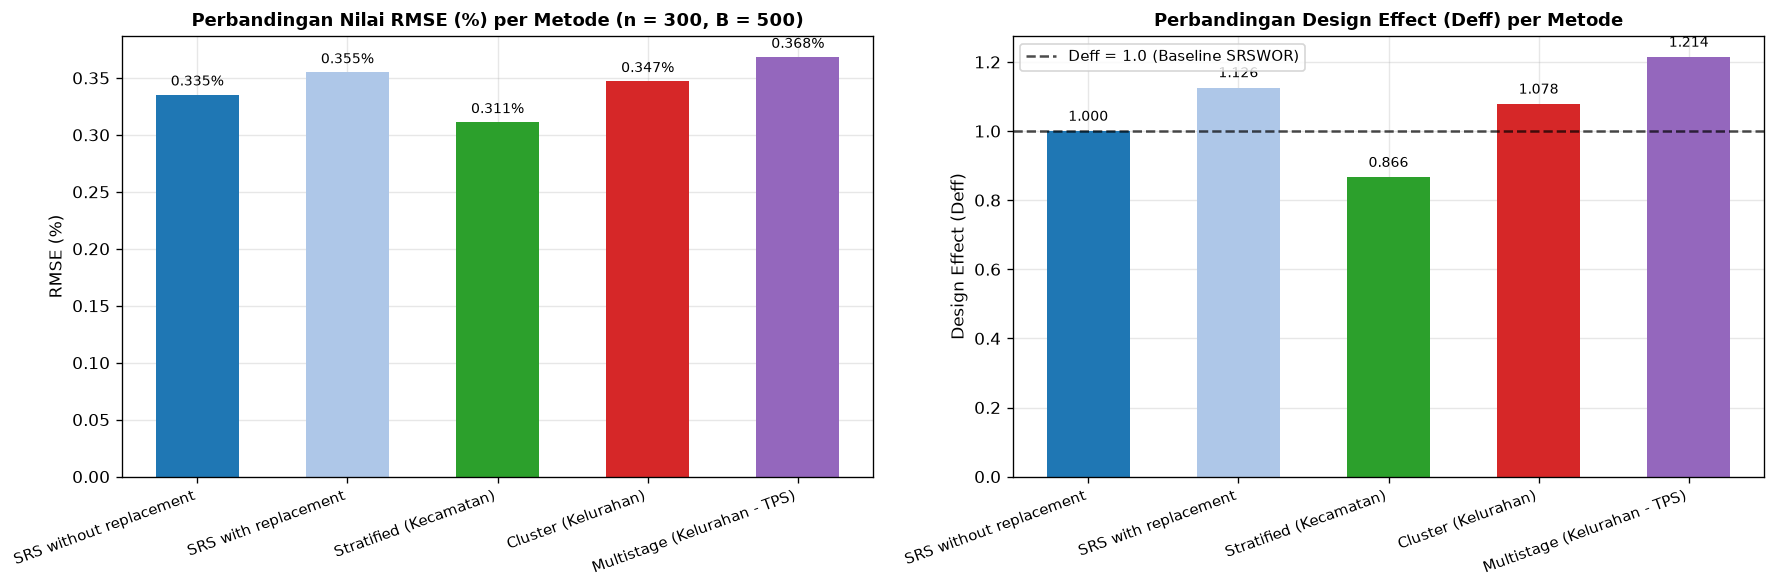

In [10]:
# Visualisasi Bar Chart Komparasi Performa Metode Sampling (RMSE & Design Effect)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

methods_list = df_mc_summary['Metode Sampling'].tolist()
rmse_vals = (df_mc_summary['RMSE'] * 100).tolist()
deff_vals = df_mc_summary['Design Effect (Deff)'].tolist()

colors_methods = ['#1f77b4', '#aec7e8', '#2ca02c', '#d62728', '#9467bd']

# Subplot 1: Bar Chart RMSE (%)
bars1 = axes[0].bar(range(len(methods_list)), rmse_vals, color=colors_methods, width=0.55)
axes[0].set_xticks(range(len(methods_list)))
axes[0].set_xticklabels(methods_list, rotation=20, ha='right', fontsize=9)
axes[0].set_title('Perbandingan Nilai RMSE (%) per Metode (n = 300, B = 500)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('RMSE (%)', fontsize=10)
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}%", ha='center', va='bottom', fontsize=8.5)

# Subplot 2: Bar Chart Design Effect (Deff)
bars2 = axes[1].bar(range(len(methods_list)), deff_vals, color=colors_methods, width=0.55)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Deff = 1.0 (Baseline SRSWOR)')
axes[1].set_xticks(range(len(methods_list)))
axes[1].set_xticklabels(methods_list, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Perbandingan Design Effect (Deff) per Metode', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Design Effect (Deff)', fontsize=10)
axes[1].legend(frameon=True, fontsize=9)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}", ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

## 6. Grafik Estimasi dan Error versus Ukuran Sampel
Analisis kurva konvergensi error ($RMSE$ dan $Margin of Error$) terhadap ukuran sampel $n \in [50, 100, 200, 300, 400, 500, 750, 1000]$. Nilai error menurun proporsional terhadap $1/\sqrt{n}$.

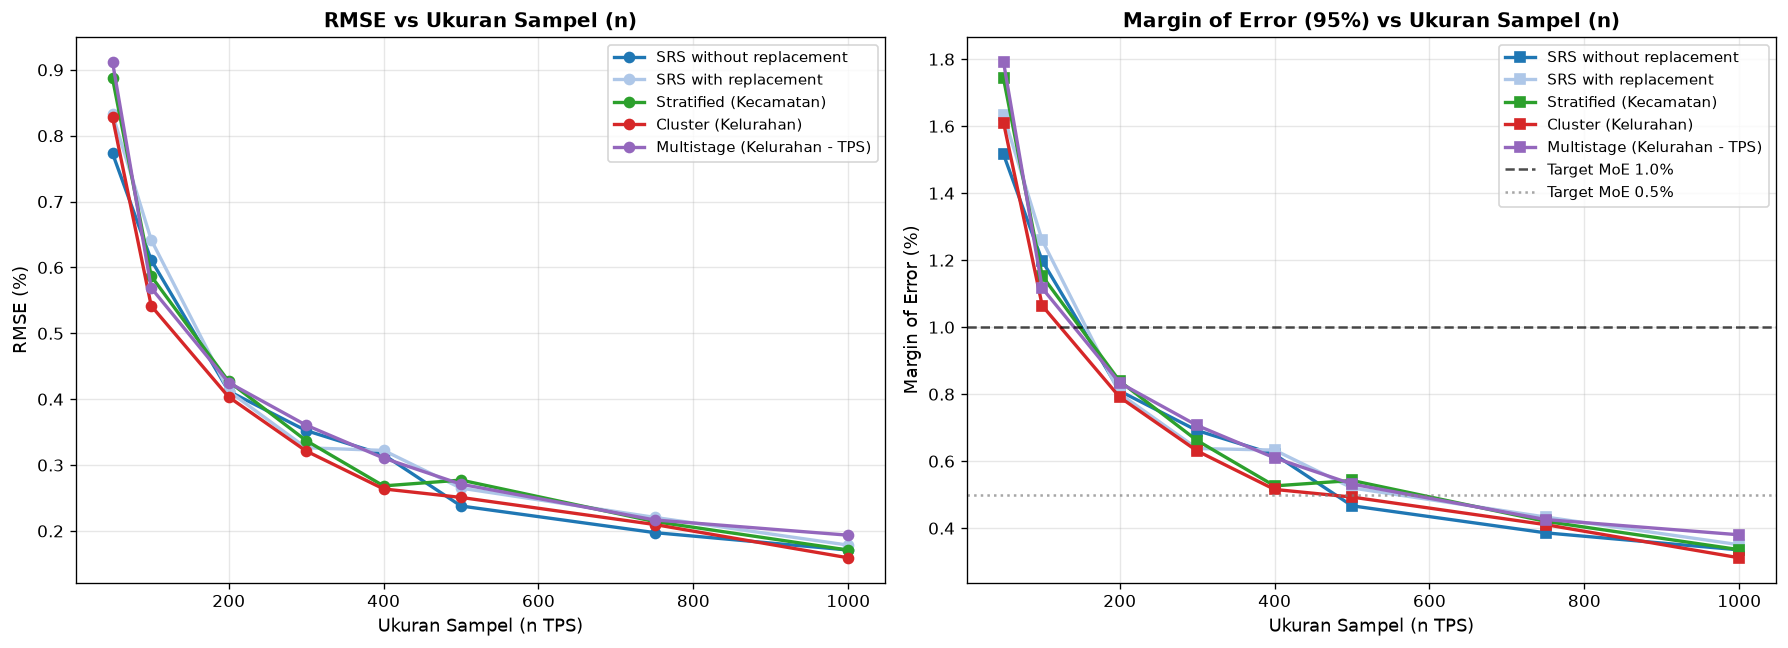

In [11]:
sample_sizes = [50, 100, 200, 300, 400, 500, 750, 1000]
B_curve = 200

curve_data = {
    'SRS without replacement': {'rmse': [], 'moe': []},
    'SRS with replacement': {'rmse': [], 'moe': []},
    'Stratified (Kecamatan)': {'rmse': [], 'moe': []},
    'Cluster (Kelurahan)': {'rmse': [], 'moe': []},
    'Multistage (Kelurahan - TPS)': {'rmse': [], 'moe': []}
}

y_pop = sampler.df['suara_paslon_02'].values
m_pop = sampler.df['total_suara_sah'].values

for n_val in sample_sizes:
    res_srswor = np.zeros(B_curve)
    res_srswr = np.zeros(B_curve)
    res_strat = np.zeros(B_curve)
    res_clust = np.zeros(B_curve)
    res_multi = np.zeros(B_curve)
    
    for b in range(B_curve):
        i1, _ = sampler.sample_srswor(n_val)
        res_srswor[b] = y_pop[i1].sum() / m_pop[i1].sum()
        
        i2, _ = sampler.sample_srswr(n_val)
        res_srswr[b] = y_pop[i2].sum() / m_pop[i2].sum()
        
        i3, w3 = sampler.sample_stratified(n_val)
        res_strat[b] = np.sum(y_pop[i3] * w3) / np.sum(m_pop[i3] * w3)
        
        i4, _ = sampler.sample_cluster(n_target=n_val)
        res_clust[b] = y_pop[i4].sum() / m_pop[i4].sum()
        
        i5, w5 = sampler.sample_multistage(n_target=n_val, m_tps=5)
        res_multi[b] = np.sum(y_pop[i5] * w5) / np.sum(m_pop[i5] * w5)
        
    for m_key, arr in [
        ('SRS without replacement', res_srswor),
        ('SRS with replacement', res_srswr),
        ('Stratified (Kecamatan)', res_strat),
        ('Cluster (Kelurahan)', res_clust),
        ('Multistage (Kelurahan - TPS)', res_multi)
    ]:
        rmse_val = np.sqrt(np.mean((arr - P_02) ** 2))
        se_val = np.std(arr, ddof=1)
        curve_data[m_key]['rmse'].append(rmse_val * 100)
        curve_data[m_key]['moe'].append(1.96 * se_val * 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

colors = {
    'SRS without replacement': '#1f77b4',
    'SRS with replacement': '#aec7e8',
    'Stratified (Kecamatan)': '#2ca02c',
    'Cluster (Kelurahan)': '#d62728',
    'Multistage (Kelurahan - TPS)': '#9467bd'
}

# Subplot 1: RMSE vs n
for m_key in curve_data:
    axes[0].plot(sample_sizes, curve_data[m_key]['rmse'], marker='o', linewidth=2, label=m_key, color=colors[m_key])
axes[0].set_title('RMSE vs Ukuran Sampel (n)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ukuran Sampel (n TPS)', fontsize=11)
axes[0].set_ylabel('RMSE (%)', fontsize=11)
axes[0].legend(frameon=True, fontsize=9)

# Subplot 2: MoE vs n
for m_key in curve_data:
    axes[1].plot(sample_sizes, curve_data[m_key]['moe'], marker='s', linewidth=2, label=m_key, color=colors[m_key])
axes[1].axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Target MoE 1.0%')
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='Target MoE 0.5%')
axes[1].set_title('Margin of Error (95%) vs Ukuran Sampel (n)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ukuran Sampel (n TPS)', fontsize=11)
axes[1].set_ylabel('Margin of Error (%)', fontsize=11)
axes[1].legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

## 7. Sampling Distribution dan Boxplot Estimator
Perbandingan bentuk sebaran estimator dan variabilitas interkuartil (IQR) pada $n = 300$ TPS ($B = 500$ iterasi) terhadap parameter riil $P = 48.0553\%$. 

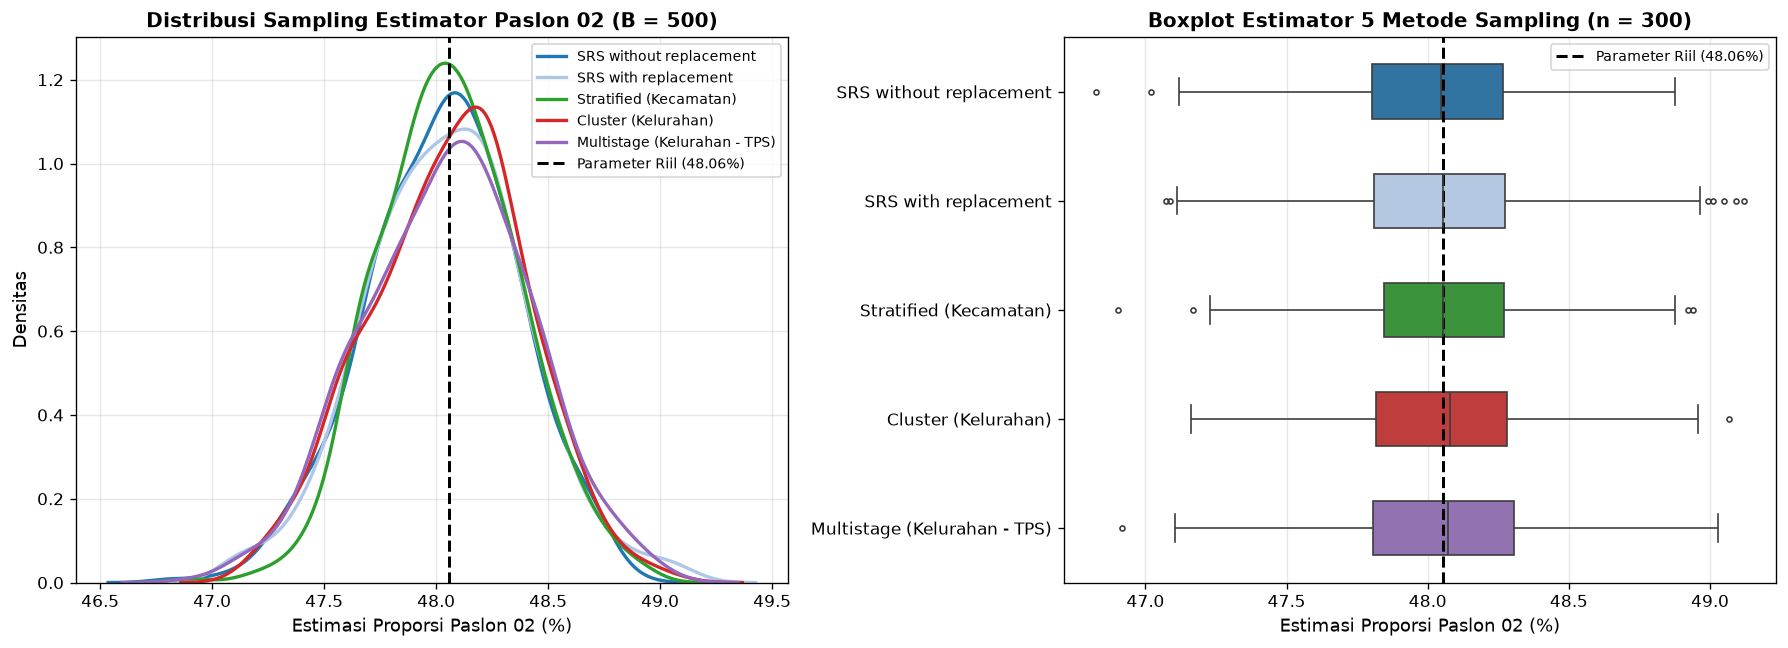

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Subplot 1: Sampling Distribution (KDE)
for m_name, vals in mc_raw_results.items():
    sns.kdeplot(vals * 100, ax=axes[0], label=m_name, linewidth=2, color=colors[m_name])
axes[0].axvline(P_02 * 100, color='black', linestyle='--', linewidth=1.8, label=f"Parameter Riil ({P_02*100:.2f}%)")
axes[0].set_title('Distribusi Sampling Estimator Paslon 02 (B = 500)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Estimasi Proporsi Paslon 02 (%)', fontsize=11)
axes[0].set_ylabel('Densitas', fontsize=11)
axes[0].legend(frameon=True, fontsize=8.5)

# Subplot 2: Boxplot Estimator
df_box = pd.DataFrame({k: v * 100 for k, v in mc_raw_results.items()})
sns.boxplot(data=df_box, ax=axes[1], palette=colors, orient='h', width=0.5, fliersize=3)
axes[1].axvline(P_02 * 100, color='black', linestyle='--', linewidth=1.8, label=f"Parameter Riil ({P_02*100:.2f}%)")
axes[1].set_title('Boxplot Estimator 5 Metode Sampling (n = 300)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Estimasi Proporsi Paslon 02 (%)', fontsize=11)
axes[1].legend(frameon=True, fontsize=8.5, loc='upper right')

plt.tight_layout()
plt.show()

## 8. Kesimpulan dan Rekomendasi Metode
Evaluasi empiris hasil simulasi Quick Count Kota Semarang (N = 4.856 TPS, n = 300 TPS, B = 500 iterasi):

1. Evaluasi Statistik dan Presisi:
   - Stratified Sampling (strata kecamatan) menghasilkan varians dan RMSE terendah (RMSE 0.31%, Deff = 0.87). Stratifikasi proporsional mengeliminasi heterogenitas antar-wilayah dan memastikan representasi berimbang di seluruh 16 kecamatan.
   - SRSWOR memiliki presisi sedikit lebih unggul dibanding SRSWR berkat faktor koreksi populasi berhingga (fpc = 1 - n/N).
   - Cluster Sampling dan Multistage Sampling memiliki varians sedikit lebih tinggi (Deff 1.08 - 1.21) karena efek homogenitas internal dalam kelurahan (intra-cluster correlation).

2. Evaluasi Operasional dan Logistik Lapangan:
   - SRSWOR dan Stratified Sampling murni menuntut penyebaran relawan di ratusan TPS yang tersebar acak secara geografis, meningkatkan beban transportasi dan supervisi lapangan.
   - Multistage Sampling (Two-Stage: pemilihan 60 kelurahan, dilanjutkan 5 TPS per kelurahan) mengonsolidasikan area pemantauan, sehingga memotong biaya logistik, mempermudah koordinasi saksi, dan mempercepat rekapitulasi data.

3. Rekomendasi Metode Final:
   - Rekomendasi Utama (Akurasi Maksimum): Stratified Sampling dengan ukuran sampel n = 300 - 400 TPS. Menghasilkan Margin of Error di kisaran ±0.60% pada tingkat kepercayaan 95%.
   - Rekomendasi Praktis (Efisiensi Biaya dan Logistik Lapangan): Multistage Two-Stage Sampling dengan ukuran sampel n = 350 TPS (70 kelurahan x 5 TPS). Menghasilkan Margin of Error sekitar ±0.75%, jauh di bawah ambang batas toleransi industri quick count (1.0%).